In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('..')
os.makedirs('../outputs', exist_ok=True)

X_train_sc = np.load('/kaggle/input/datasets/aymennoor/audio-files/X_train_sc.npy')
X_test_sc  = np.load('/kaggle/input/datasets/aymennoor/audio-files/X_test_sc.npy')
y_train    = np.load('/kaggle/input/datasets/aymennoor/audio-files/y_train.npy')
y_test     = np.load('/kaggle/input/datasets/aymennoor/audio-files/y_test.npy')
feat_cols  = pd.read_csv('/kaggle/input/datasets/aymennoor/audio-files/feature_names.csv').iloc[:, 0].tolist()

EMOTION_NAMES = {
    1:'neutral', 2:'calm',    3:'happy',    4:'sad',
    5:'angry',   6:'fearful', 7:'disgust',  8:'surprised'
}
LABELS = [EMOTION_NAMES[i] for i in sorted(EMOTION_NAMES.keys())]

print(f'Train : {X_train_sc.shape}')
print(f'Test  : {X_test_sc.shape}')

Train : (1956, 112)
Test  : (496, 112)


In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [4]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

Xtr = torch.tensor(X_train_sc, dtype=torch.float32)
ytr = torch.tensor(y_train_enc, dtype=torch.long)
Xte = torch.tensor(X_test_sc, dtype=torch.float32)
yte = torch.tensor(y_test_enc, dtype=torch.long)

dataset = TensorDataset(Xtr, ytr)

val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

In [5]:
class SER_MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
model = SER_MLP(
    input_dim=X_train_sc.shape[1],
    num_classes=len(le.classes_)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [7]:
best_val_loss = float("inf")
best_state = None
patience = 15
wait = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, 151):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)
            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_true.extend(yb.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(val_true, val_preds)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        print("Early stopping.")
        break

model.load_state_dict(best_state)

Epoch 001 | train_loss=1.8920 | val_loss=1.6933 | val_acc=0.3581
Epoch 002 | train_loss=1.6003 | val_loss=1.5320 | val_acc=0.4450
Epoch 003 | train_loss=1.4394 | val_loss=1.3710 | val_acc=0.5320
Epoch 004 | train_loss=1.3041 | val_loss=1.2493 | val_acc=0.5857
Epoch 005 | train_loss=1.1864 | val_loss=1.1754 | val_acc=0.5959
Epoch 006 | train_loss=1.0813 | val_loss=1.0833 | val_acc=0.6240
Epoch 007 | train_loss=1.0020 | val_loss=1.0189 | val_acc=0.6394
Epoch 008 | train_loss=0.9260 | val_loss=0.9787 | val_acc=0.6547
Epoch 009 | train_loss=0.8798 | val_loss=0.9133 | val_acc=0.6854
Epoch 010 | train_loss=0.8329 | val_loss=0.9073 | val_acc=0.6829
Epoch 011 | train_loss=0.7921 | val_loss=0.8813 | val_acc=0.6957
Epoch 012 | train_loss=0.7373 | val_loss=0.8370 | val_acc=0.7161
Epoch 013 | train_loss=0.7396 | val_loss=0.8471 | val_acc=0.6957
Epoch 014 | train_loss=0.7387 | val_loss=0.8388 | val_acc=0.7059
Epoch 015 | train_loss=0.7112 | val_loss=0.8394 | val_acc=0.6982
Epoch 016 | train_loss=0.

<All keys matched successfully>

In [8]:
model.eval()

with torch.no_grad():
    logits = model(Xte.to(device))
    y_pred_enc = torch.argmax(logits, dim=1).cpu().numpy()

y_pred = le.inverse_transform(y_pred_enc)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"ANN Accuracy: {acc:.4f}")
print(f"ANN Macro F1: {f1:.4f}")
print()
print(classification_report(y_test, y_pred))

ANN Accuracy: 0.7177
ANN Macro F1: 0.7239

              precision    recall  f1-score   support

           1       0.76      0.76      0.76        38
           2       0.71      0.80      0.75        76
           3       0.68      0.78      0.72        76
           4       0.66      0.54      0.59        76
           5       0.83      0.79      0.81        76
           6       0.62      0.66      0.64        76
           7       0.74      0.72      0.73        39
           8       0.85      0.72      0.78        39

    accuracy                           0.72       496
   macro avg       0.73      0.72      0.72       496
weighted avg       0.72      0.72      0.72       496



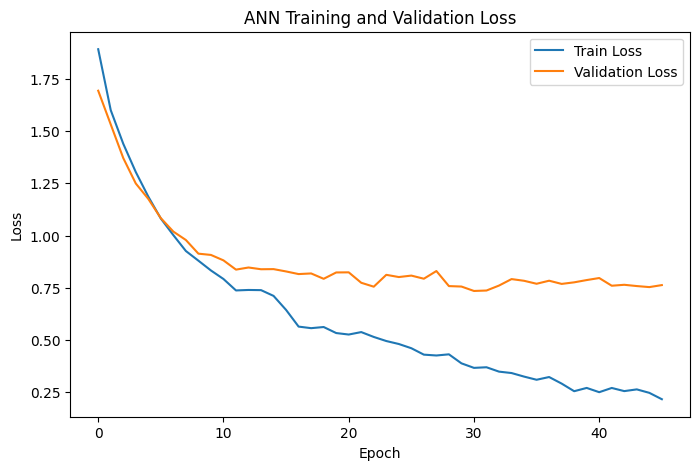

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.show()

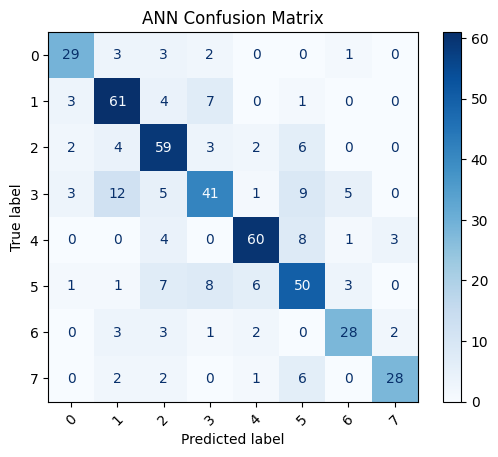

In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("ANN Confusion Matrix")
plt.show()

## Summary

- This notebook applied a dense Artificial Neural Network (ANN) to the standardized 112-dimensional Speech Emotion Recognition feature dataset.

- The ANN was implemented using PyTorch and trained on GPU when CUDA was available. The model used fully connected layers, batch normalization, ReLU activations, dropout regularization, AdamW optimization, and early stopping.

- The final ANN achieved approximately:
  - Accuracy ≈ 0.718
  - Macro F1 ≈ 0.724

- These results were competitive with the best earlier machine learning models, particularly the RBF SVM. This confirms that the SER feature space contains strong non-linear structure.

- Training and validation loss curves showed that the model began to overfit after roughly 15–20 epochs. Early stopping successfully prevented excessive memorization of the training data.

- The ANN performed well because neural networks can model complex nonlinear interactions between MFCCs, RMS energy, ZCR, chroma, and spectral features.

- Some emotions remained difficult to separate, especially emotions with similar acoustic patterns or arousal levels. This is visible in the confusion matrix and reflects the intrinsic difficulty of Speech Emotion Recognition.

- Compared with simpler linear models, the ANN learned more flexible decision boundaries. However, because the dataset is relatively small and based on handcrafted summary features, the ANN did not dramatically outperform the optimized RBF SVM.

- Overall, the ANN validated the project conclusion that emotional speech classification benefits strongly from nonlinear modeling approaches.